In [1]:
# Import required libraries
import pickle
from sklearnex import patch_sklearn
patch_sklearn()

import warnings
warnings.filterwarnings(
    "ignore"
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from sklearn.model_selection import learning_curve

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
DATA_DIR = "./MP_DATA"

POSE_PATH = rf"./{DATA_DIR}/pose"
RIGHT_PATH = rf"./{DATA_DIR}/right"
LEFT_PATH = rf"./{DATA_DIR}/left"

SAVE_PATH = "./Models"

In [3]:
def compute_accuracy(true, pred):
    """
    Computes the accuracy as (number of matching labels / total labels).
    """
    correct_predictions = sum(1 for true_label, predicted in zip(true, pred) if true_label == predicted)
    return correct_predictions / len(true)

def train_model(DATA_PATH:str,SAVE_PATH:str,SAVE_NAME:str) -> tuple:
    """Train a Random Forest model on the given data.

    Args:
        DATA_PATH (str): Path to the input data (JSON file without extension).
        SAVE_PATH (str): Directory where the model will be saved.
        SAVE_NAME (str): Name of the saved model file (without extension).

    Returns:
        tuple: A tuple containing the trained model and the train/test splits.
    """
    
    
    # Load pose angle data from a json file
    with open(rf'{DATA_PATH}.json', 'r') as f:
        angles_dict = json.load(f)


    data = np.array(angles_dict['data'])   
    labels = np.array(angles_dict['labels'])

    x_train, x_test, y_train, y_test = train_test_split(
        data,
        labels,
        test_size=0.2,
        shuffle=True,
        stratify=labels
    )

    model = RandomForestClassifier(
        n_estimators=100,      
        max_depth=6,           
        min_samples_split=3,   
        min_samples_leaf=2,    
        bootstrap=True,        
        criterion='entropy',   
        oob_score=True         
    )

    model.fit(x_train, y_train)

    y_predict = model.predict(x_test)
    accuracy_score = compute_accuracy(y_test, y_predict)
    print(f"{accuracy_score * 100:.2f}% of samples were classified correctly!")

    
    
    # Save the trained model as a pickle file
    with open(rf'.\{SAVE_PATH}\{SAVE_NAME}.p', 'wb') as f:
        pickle.dump({'model': model}, f)


    return model, data, labels, x_train, x_test, y_test, y_predict


def model_evaluation(model,x_train, y_test, y_pred ,data, labels):
    """Evaluates the model using various metrics and visualizations."""

    # Cross-Validation (k=5)
    cross_val_score_mean = cross_val_score(model, data, labels, cv=5).mean()
    print(f"\nCross-Validation Score (5-fold): {cross_val_score_mean * 100:.2f}%")

    # Out-of-Bag Score (if applicable)
    oob_score = model.oob_score_ if hasattr(model, 'oob_score_') else 'N/A'
    print(f"\nOut-of-Bag (OOB) Score: {oob_score}")
    
    conf_matrix = metrics.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=np.unique(y_test),
        yticklabels=np.unique(y_test)
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    """Prints classification report"""
    print("\nClassification Report:")
    print(metrics.classification_report(y_test, y_pred))


    # Feature Importance
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances")
    plt.bar(range(x_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(x_train.shape[1]), indices, rotation=90)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()



    # 6. Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        data,
        labels,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color='blue')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation Score", color='green')
    plt.title('Learning Curve')
    plt.xlabel('Training Set Size')
    plt.ylabel('Score')
    plt.legend()
    plt.show()





# POSE

83.53% of samples were classified correctly!

Cross-Validation Score (5-fold): 76.13%

Out-of-Bag (OOB) Score: 0.8170607678616832


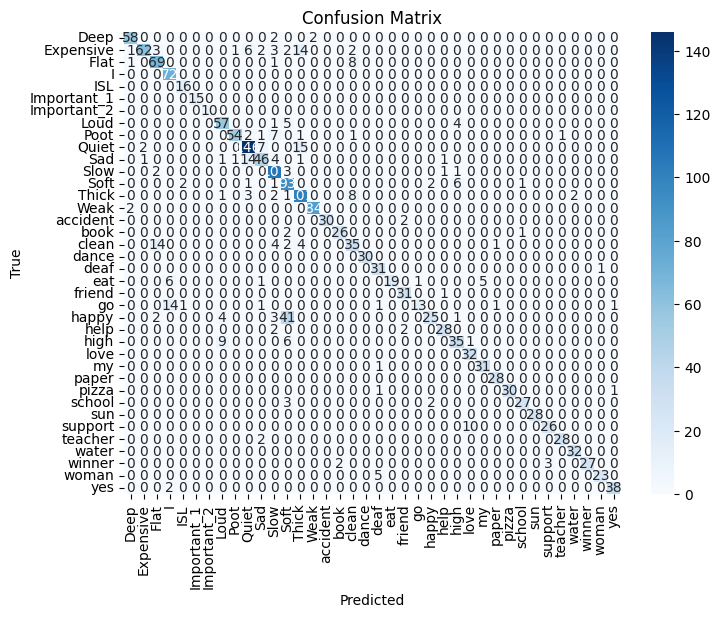


Classification Report:
              precision    recall  f1-score   support

        Deep       0.94      0.94      0.94        62
   Expensive       0.95      0.65      0.77        96
        Flat       0.77      0.87      0.82        79
           I       0.77      1.00      0.87        72
         ISL       0.84      1.00      0.91        16
 Important_1       1.00      1.00      1.00        15
 Important_2       1.00      1.00      1.00        10
        Loud       0.79      0.85      0.82        67
        Poot       0.96      0.81      0.88        67
       Quiet       0.85      0.86      0.85       170
         Sad       0.77      0.67      0.71        69
        Slow       0.78      0.94      0.85       114
        Soft       0.59      0.88      0.70       106
       Thick       0.74      0.86      0.80       118
        Weak       0.98      0.98      0.98        86
    accident       1.00      0.94      0.97        32
        book       0.93      0.90      0.91        29
   

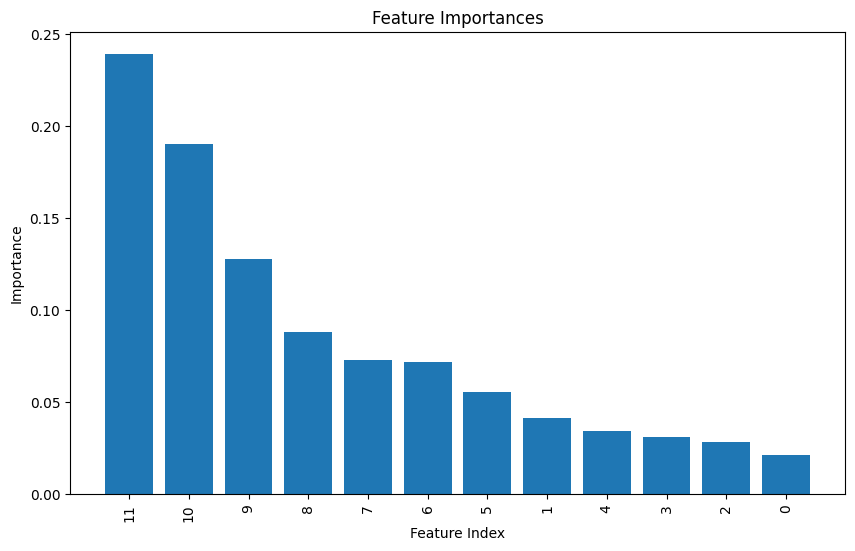

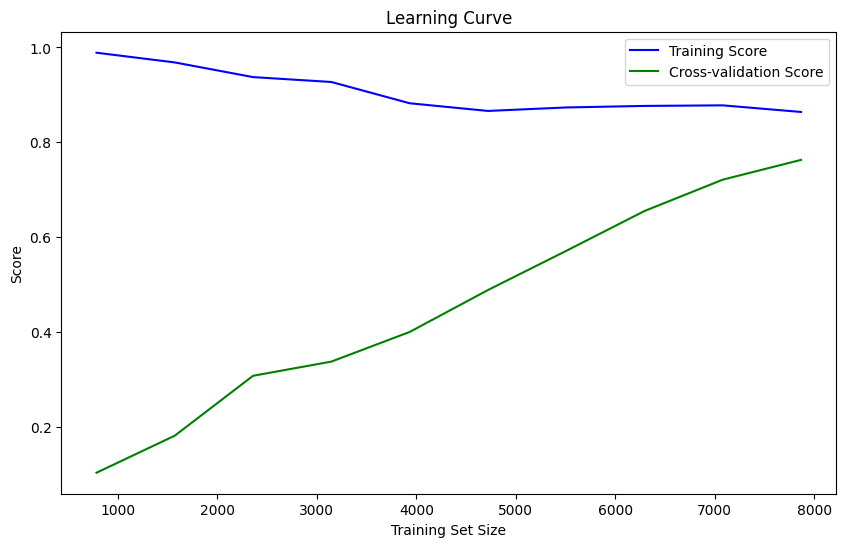

In [4]:
pose_model,pose_data,pose_labels,x_train, x_test, y_test, y_predict=train_model(POSE_PATH, SAVE_PATH, "pose_model")
model_evaluation(pose_model, x_train, y_test, y_predict, pose_data, pose_labels)


# RIGHT

93.47% of samples were classified correctly!

Cross-Validation Score (5-fold): 92.44%

Out-of-Bag (OOB) Score: 0.9384843982169391


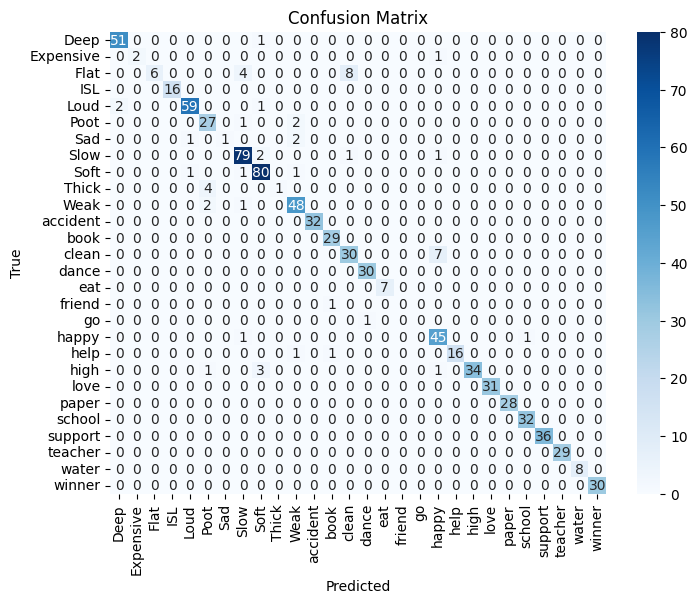


Classification Report:
              precision    recall  f1-score   support

        Deep       0.96      0.98      0.97        52
   Expensive       1.00      0.67      0.80         3
        Flat       1.00      0.33      0.50        18
         ISL       1.00      1.00      1.00        16
        Loud       0.97      0.95      0.96        62
        Poot       0.79      0.90      0.84        30
         Sad       1.00      0.25      0.40         4
        Slow       0.91      0.95      0.93        83
        Soft       0.92      0.96      0.94        83
       Thick       1.00      0.20      0.33         5
        Weak       0.89      0.94      0.91        51
    accident       1.00      1.00      1.00        32
        book       0.94      1.00      0.97        29
       clean       0.77      0.81      0.79        37
       dance       0.97      1.00      0.98        30
         eat       1.00      1.00      1.00         7
      friend       0.00      0.00      0.00         1
   

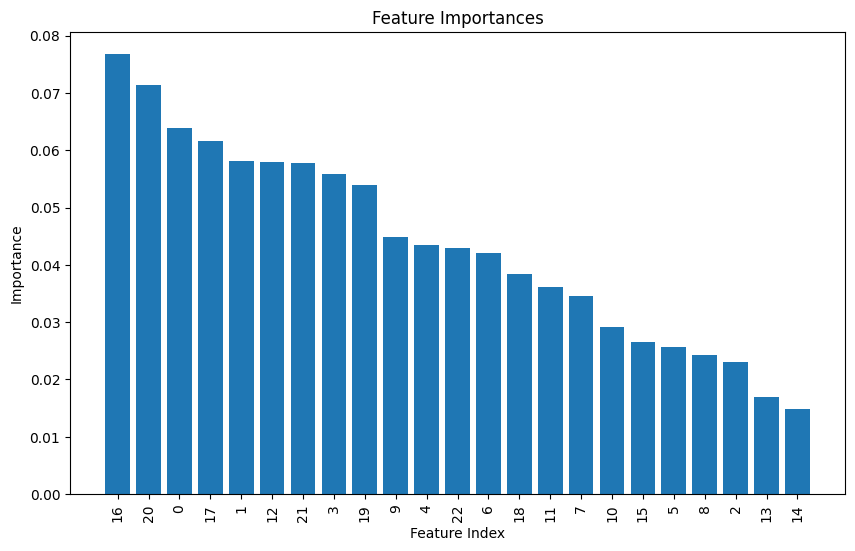

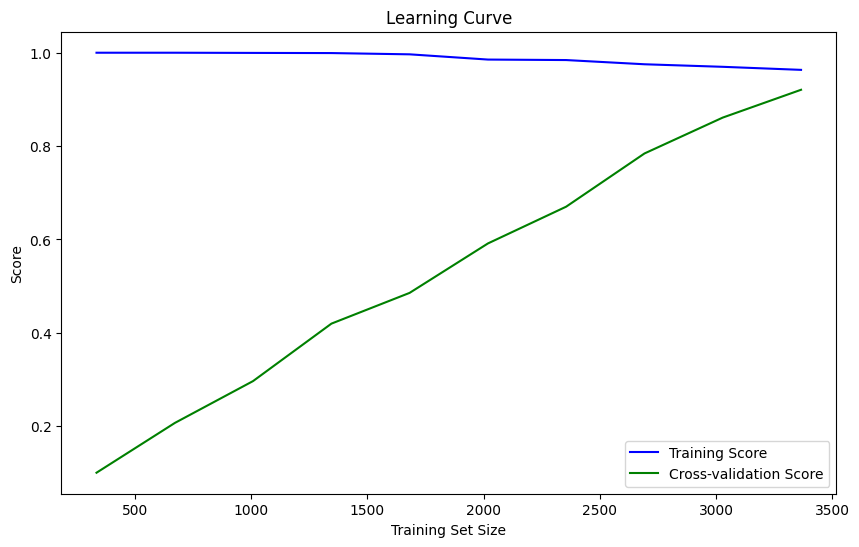

In [5]:
# Evaluate Models
right_model,right_data,right_labels,x_train, x_test, y_test, y_predict=train_model(RIGHT_PATH, SAVE_PATH, "right_model")
model_evaluation(right_model, x_train, y_test, y_predict, right_data, right_labels)


# LEFT

91.65% of samples were classified correctly!

Cross-Validation Score (5-fold): 89.46%

Out-of-Bag (OOB) Score: 0.9109060656481621


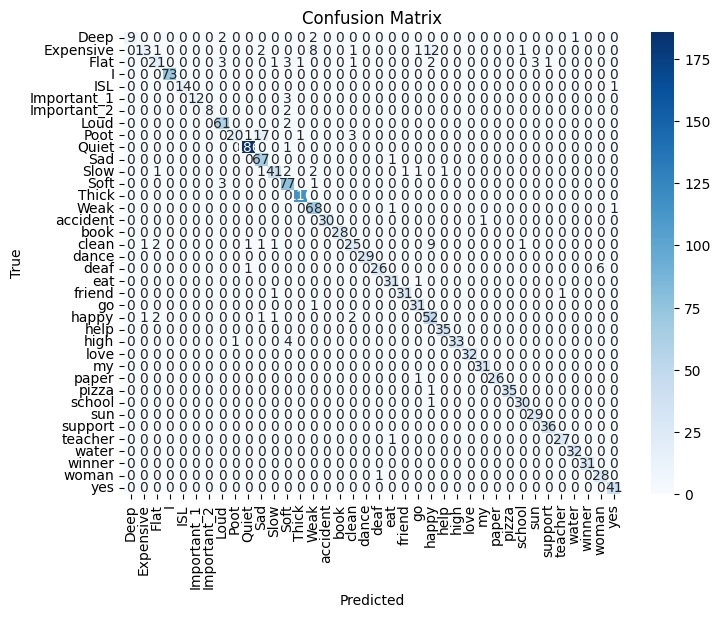


Classification Report:
              precision    recall  f1-score   support

        Deep       1.00      0.64      0.78        14
   Expensive       0.87      0.33      0.48        39
        Flat       0.78      0.58      0.67        36
           I       1.00      1.00      1.00        73
         ISL       1.00      0.93      0.97        15
 Important_1       1.00      0.80      0.89        15
 Important_2       1.00      0.80      0.89        10
        Loud       0.88      0.97      0.92        63
        Poot       0.95      0.48      0.63        42
       Quiet       0.98      0.99      0.99       187
         Sad       0.75      0.99      0.85        68
        Slow       0.91      0.82      0.86        50
        Soft       0.82      0.95      0.88        81
       Thick       0.98      1.00      0.99       116
        Weak       0.83      0.97      0.89        70
    accident       1.00      0.97      0.98        31
        book       1.00      1.00      1.00        28
   

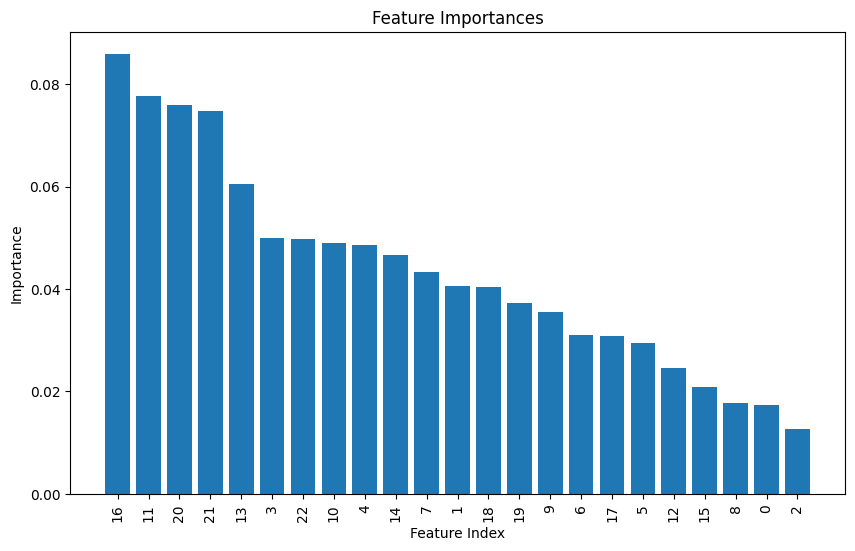

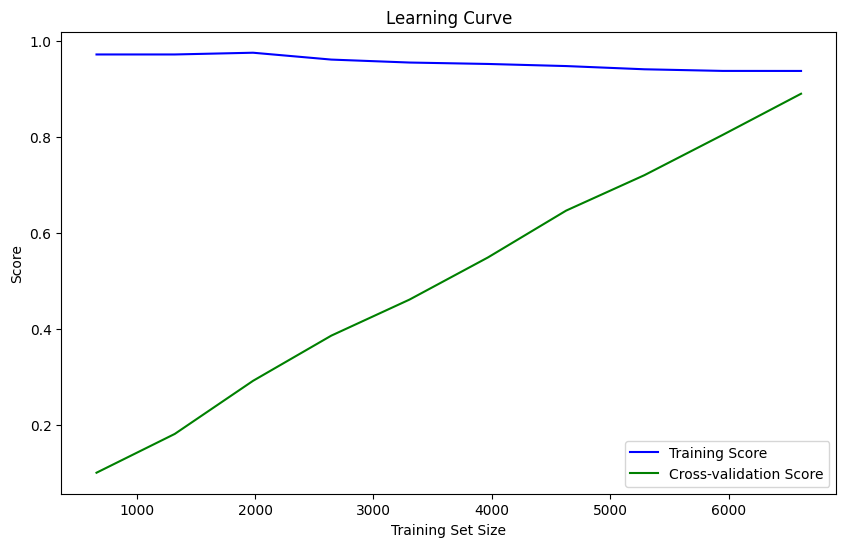

In [6]:

left_model,left_data,left_labels,x_train, x_test, y_test, y_predict=train_model(LEFT_PATH, SAVE_PATH, "left_model")
model_evaluation(left_model, x_train, y_test, y_predict, left_data, left_labels)